# Temporal Congestion Analysis

This notebook explores the possibility that port congestion signals may persist across operational cycles.

While the baseline exploratory analysis focused on same-month operational signals, congestion within port logistics systems often propagates over time. Container accumulation, evacuation delays, and gate congestion may create delayed effects that influence dwell times in subsequent months.

The objective of this notebook is therefore to investigate whether previous-month operational conditions exhibit relationships with current congestion indicators.

If such temporal persistence is observed, lagged operational features will be engineered in the subsequent feature engineering stage.

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (12,8)

## Loading Cleaned Dataset

The dataset used in this analysis is the cleaned operational dataset produced in the data preprocessing stage.

The dataset contains monthly observations of container throughput, dwell times, evacuation indicators, and transit variables related to JNPA port logistics operations.

In [2]:
df = pd.read_csv("../../data/JNPA_Cleaned_Data.csv")

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date").reset_index(drop=True)

df.head()

,Month-Year,Imp_Dwell_Overall,Imp_Dwell_Truck,Imp_Dwell_Train,Parking_Dwell,Imp_Transit_CFS,Imp_Transit_ICD,Exp_Dwell_Overall,Exp_Dwell_Truck,Exp_Dwell_Train,Exp_Transit_CFS,Exp_Transit_ICD,Total_TEUs_Handled,Date
0,Jan 23,21.9,18.2,86.3,1.88,2.86,83.2,70.9,70.5,73.4,4.45,107.6,522592,2023-01-01
1,Feb 23,27.8,24.0,69.6,2.55,2.78,79.0,69.5,67.8,80.7,5.06,109.2,467614,2023-02-01
2,Mar 23,26.5,22.3,63.7,3.65,2.47,97.1,74.0,72.4,86.1,6.42,113.0,560076,2023-03-01
3,Apr 23,29.9,25.4,53.2,4.00,2.62,90.1,80.0,77.1,104.6,6.46,89.3,503668,2023-04-01
4,May 23,19.9,17.2,51.0,2.33,2.56,91.1,65.0,62.8,81.3,4.21,109.6,538247,2023-05-01


## Temporal Congestion Hypothesis

Port congestion rarely occurs as an isolated monthly event.

Operational disruptions such as vessel bunching, rail evacuation delays, gate congestion, and seasonal weather effects can propagate through the logistics system across multiple operational cycles.

Containers accumulated during one month may remain within the yard or evacuation network during the following month, creating delayed congestion pressure that affects dwell time performance.

This hypothesis suggests that previous-month operational conditions may contain predictive signals for current congestion risk.

To examine this possibility, lagged versions of key operational indicators are explored in the following analysis.

## Creating Lagged Operational Signals for Analysis

To evaluate delayed congestion effects, lagged versions of key operational variables are temporarily created for exploratory analysis.

These lagged signals represent operational conditions from the previous month.

In [3]:
df["Volume_Lag1"] = df["Total_TEUs_Handled"].shift(1)

df["Parking_Dwell_Lag1"] = df["Parking_Dwell"].shift(1)

df["Rail_Friction"] = df["Imp_Dwell_Train"] / df["Imp_Dwell_Truck"]
df["Rail_Friction_Lag1"] = df["Rail_Friction"].shift(1)

df["Is_Monsoon"] = df["Date"].dt.month.isin([6,7,8,9]).astype(int)
df["Stress"] = df["Total_TEUs_Handled"] * df["Is_Monsoon"]
df["Stress_Lag1"] = df["Stress"].shift(1)

## Lagged Throughput vs Import Dwell Time

If container accumulation contributes to delayed congestion, previous-month throughput should exhibit some relationship with current import dwell time.

Correlation between Volume_Lag1 and Import Dwell: 0.49903869592014405


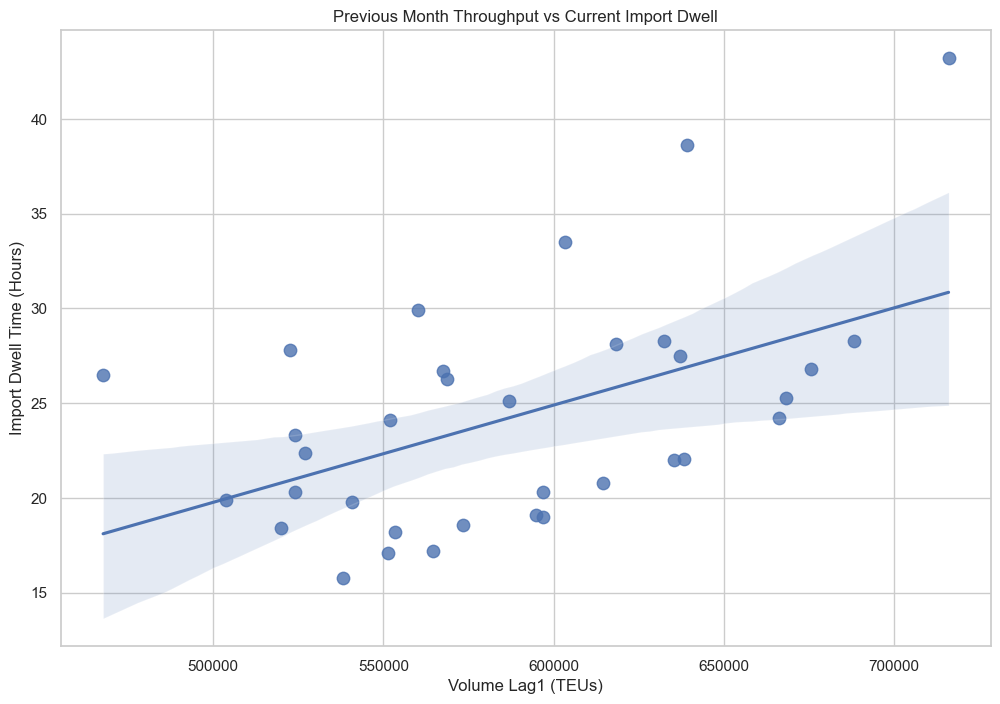

In [4]:
corr = df["Volume_Lag1"].corr(df["Imp_Dwell_Overall"])
print("Correlation between Volume_Lag1 and Import Dwell:", corr)

plt.figure()

sns.regplot(x="Volume_Lag1",y="Imp_Dwell_Overall",data=df,scatter_kws={"s":80})

plt.title("Previous Month Throughput vs Current Import Dwell")
plt.xlabel("Volume Lag1 (TEUs)")
plt.ylabel("Import Dwell Time (Hours)")
plt.show()

### Observation

Previous-month container throughput shows a moderate positive relationship with current import dwell time. This suggests that high container volumes may generate backlog pressure that persists into the following operational cycle.

## Lagged Rail Evacuation Imbalance

Rail evacuation disruptions may also persist across operational cycles.

If rail evacuation becomes unstable in one month, recovery may take multiple weeks, potentially affecting dwell performance during the following period.

Correlation between Rail_Friction_Lag1 and Import Dwell: -0.21318732429359702


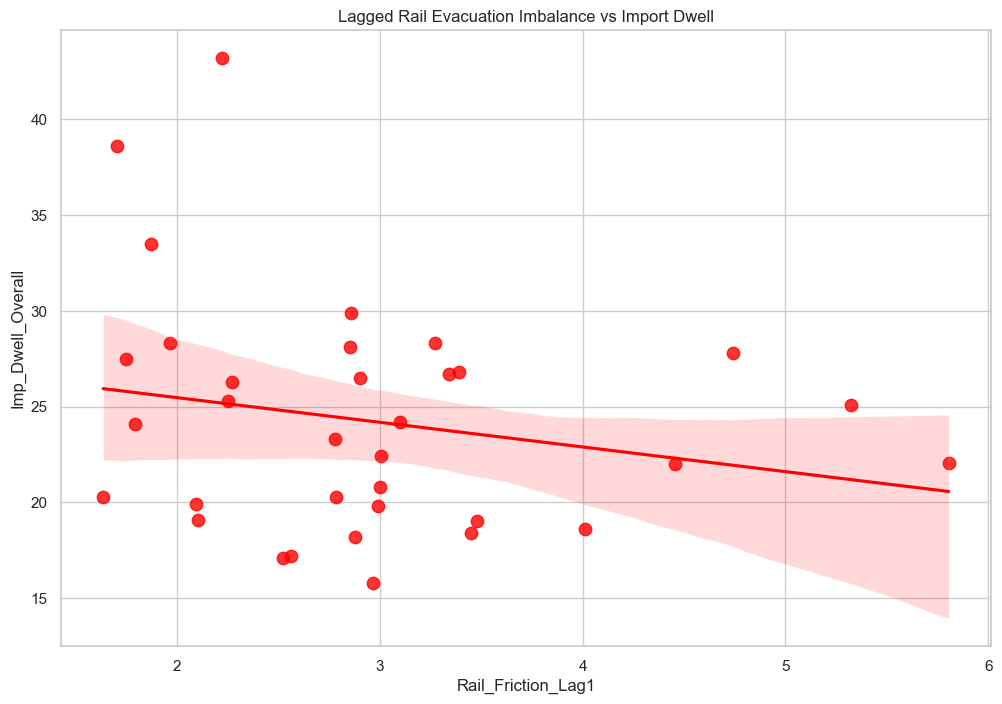

In [5]:
corr = df["Rail_Friction_Lag1"].corr(df["Imp_Dwell_Overall"])
print("Correlation between Rail_Friction_Lag1 and Import Dwell:", corr)

plt.figure()

sns.regplot(x="Rail_Friction_Lag1",y="Imp_Dwell_Overall",data=df,scatter_kws={"s":80},color="red")

plt.title("Lagged Rail Evacuation Imbalance vs Import Dwell")
plt.show()

### Observation

Lagged rail evacuation imbalance does not exhibit a strong direct relationship with current dwell time. However, this may reflect operational recovery mechanisms where evacuation disruptions in one cycle trigger modal adjustments in the subsequent cycle.

## Lagged Gate Congestion Signal

Parking dwell represents truck waiting time at the terminal gate.

Gate congestion in one operational cycle may affect yard staging and export handling conditions during the following period.

Correlation between Parking_Dwell_Lag1 and Export Dwell: -0.2395335019975821


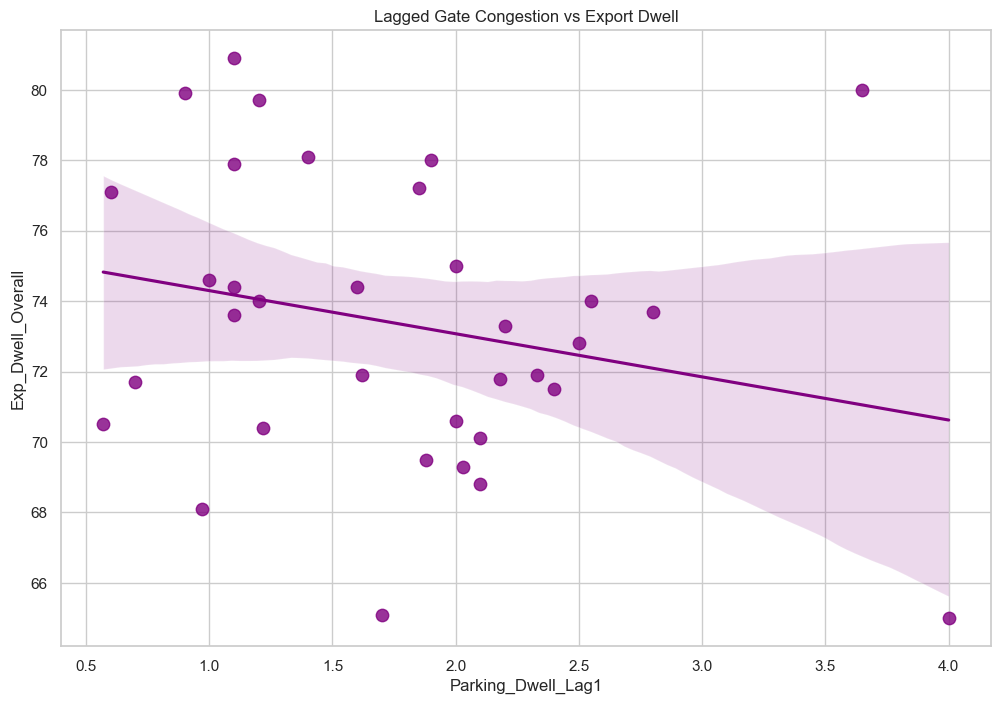

In [6]:
corr = df["Parking_Dwell_Lag1"].corr(df["Exp_Dwell_Overall"])
print("Correlation between Parking_Dwell_Lag1 and Export Dwell:", corr)

plt.figure()

sns.regplot(x="Parking_Dwell_Lag1",y="Exp_Dwell_Overall",data=df,scatter_kws={"s":80},color="purple")

plt.title("Lagged Gate Congestion vs Export Dwell")
plt.show()

### Observation
Lagged gate congestion indicators show limited direct association with export dwell times. Export staging is often influenced by vessel scheduling rather than immediate gate congestion conditions.

## Lagged Seasonal Operational Stress

Lagged seasonal stress indicators display a mild positive relationship with import dwell time. Seasonal disruptions combined with high throughput may create operational pressures that persist into subsequent months.

Correlation between Stress_Lag1 and Import Dwell: 0.32265336552975626


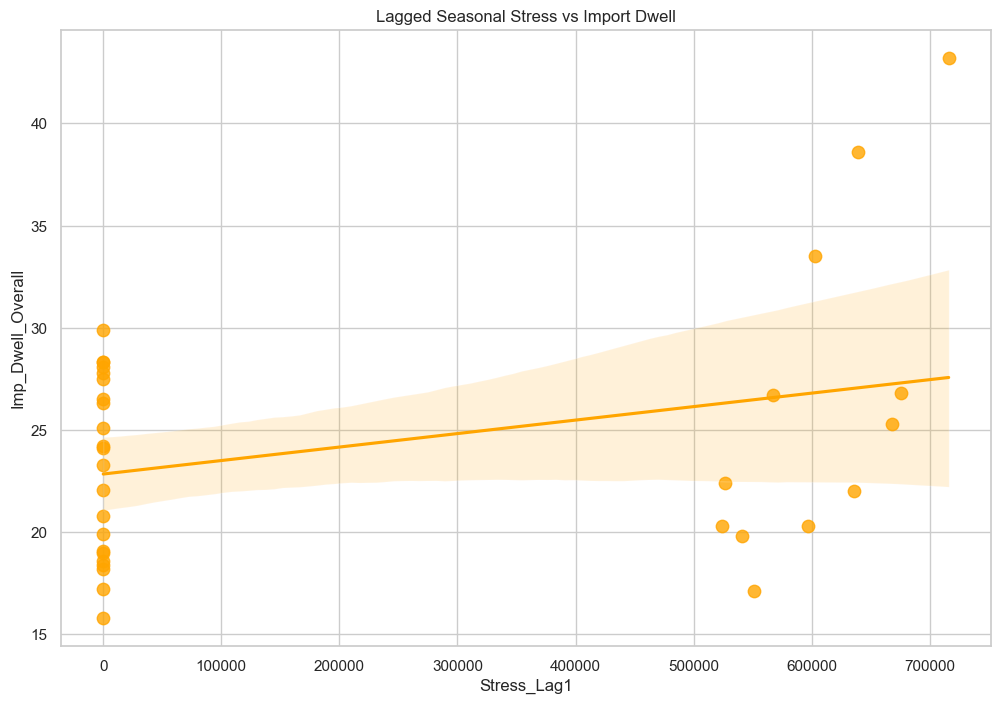

In [7]:
corr = df["Stress_Lag1"].corr(df["Imp_Dwell_Overall"])
print("Correlation between Stress_Lag1 and Import Dwell:", corr)

plt.figure()

sns.regplot(x="Stress_Lag1",y="Imp_Dwell_Overall",data=df,scatter_kws={"s":80},color="orange")

plt.title("Lagged Seasonal Stress vs Import Dwell")
plt.show()

## Summary of Temporal Observations

The exploratory analysis suggests that several operational signals may exhibit delayed effects on congestion performance.

Previous-month throughput, evacuation imbalance, gate congestion, and seasonal stress all show potential relationships with dwell conditions in the following period.

These observations support the hypothesis that port congestion may propagate across operational cycles rather than appearing as isolated monthly events.

## Temporal Feature Engineering Plan

Based on the temporal exploratory analysis, lagged versions of key operational signals will be engineered for use in an extended congestion prediction model.

The proposed lagged features are:

Volume_Lag1 – previous-month container throughput pressure

Parking_Dwell_Lag1 – delayed gate congestion signal

Rail_Friction_Lag1 – lagged rail evacuation imbalance

Stress_Lag1 – seasonal operational pressure carryover

These variables will be created in the subsequent feature engineering stage and evaluated within a temporal extension of the congestion prediction model.